# 17.2) Regressão linear simples

In [69]:
# visualizção dos gráficos dinâmicos 
# !pip install plotly --upgrade

In [70]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [71]:
base_plano_saude = pd.read_csv('plano_saude.csv')
base_plano_saude

,idade,custo
0,18,871
1,23,1132
2,28,1242
3,33,1356
4,38,1488
5,43,1638
6,48,2130
7,53,2454
8,58,3066
9,63,4090


x = atributo previsor, idade

y= custo do plano de saúde

In [72]:
X_plano_saude = base_plano_saude.iloc[:, 0].values # coleta apenas os valores da primeira coluna, idade.
X_plano_saude

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

In [73]:
y_plano_saude = base_plano_saude.iloc[:, 1].values
y_plano_saude # objetivo

array([ 871, 1132, 1242, 1356, 1488, 1638, 2130, 2454, 3066, 4090])

In [74]:
# calcular o coeficiente de correlação, ente as duas variáveis;
# valor x, valor y
np.corrcoef(X_plano_saude, y_plano_saude)

array([[1.        , 0.93091958],
       [0.93091958, 1.        ]])


correlação matriz

variáviel com a própria varíavel x , correlação do x com o y 

correlação do y com o x , variáviel com a própria varíavel 1
 
 
Explica que 93% dos dados do custo é explicado pela idade da pessoa. Indica correlação forte entre as duas variáveis. 


In [75]:
# visualizar o formato da variável.
X_plano_saude.shape # matriz de uma dimensão só, com 10 linhas apenas;

(10,)

In [76]:
X_plano_saude

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

In [77]:
X_plano_saude = X_plano_saude.reshape(-1,1)
X_plano_saude

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [78]:
X_plano_saude.shape # agora são duas dimensões, conforme o modelo necessita. Ou seja, há 10 linhas e uma coluna

(10, 1)

In [79]:
# formato alterado por conta da biblioteca sklearn

In [80]:
from sklearn.linear_model import LinearRegression # mesmo pacote da regressão logistica
regressor_plano_saude = LinearRegression() # sem configurar o parâmetro
regressor_plano_saude.fit(X_plano_saude, y_plano_saude)

LinearRegression()

In [81]:
# curiosidade em ver os parâmetros criados
regressor_plano_saude.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [82]:
# b0
regressor_plano_saude.intercept_  # constante

-558.9490909090907

início a linha de regressão => b0

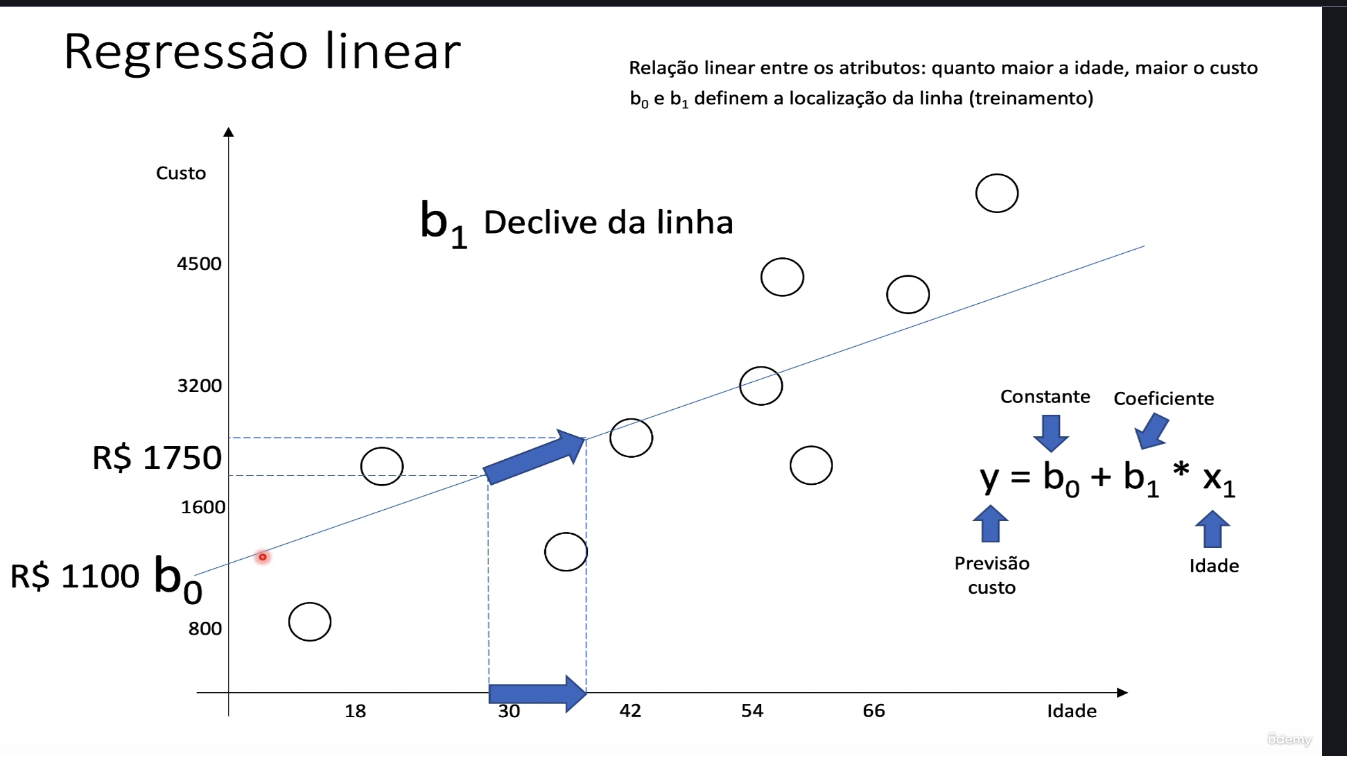

In [83]:
# b1  -> coeficiente, declive da linha
regressor_plano_saude.coef_

array([61.86787879])

In [84]:
# verificar a previsão
previsoes = regressor_plano_saude.predict(X_plano_saude)
previsoes

array([ 554.67272727,  864.01212121, 1173.35151515, 1482.69090909,
       1792.03030303, 2101.36969697, 2410.70909091, 2720.04848485,
       3029.38787879, 3338.72727273])

In [85]:
X_plano_saude

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [86]:
# voltando o eixo x para o formato de vetor, pois está no formato de matriz, com linha e coluna antes, agora quero só linha. 
X_plano_saude.ravel()

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

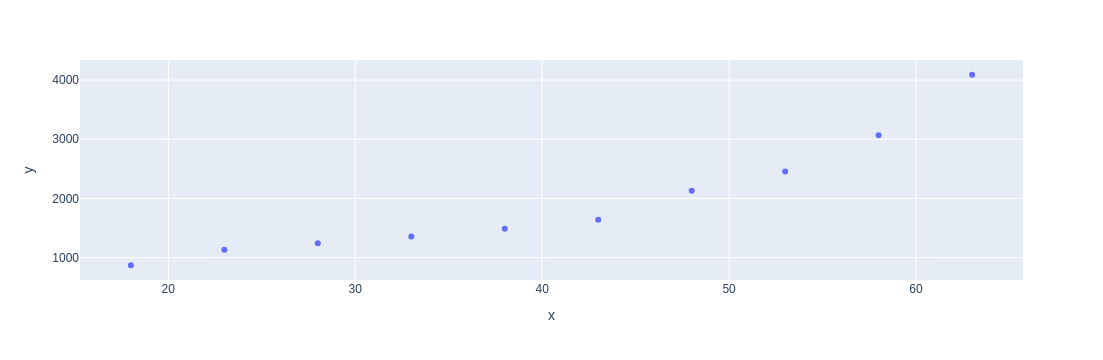

In [87]:
grafico = px.scatter(x = X_plano_saude.ravel(), y = y_plano_saude) # apenas a visualização dos pontos. 
grafico.show()

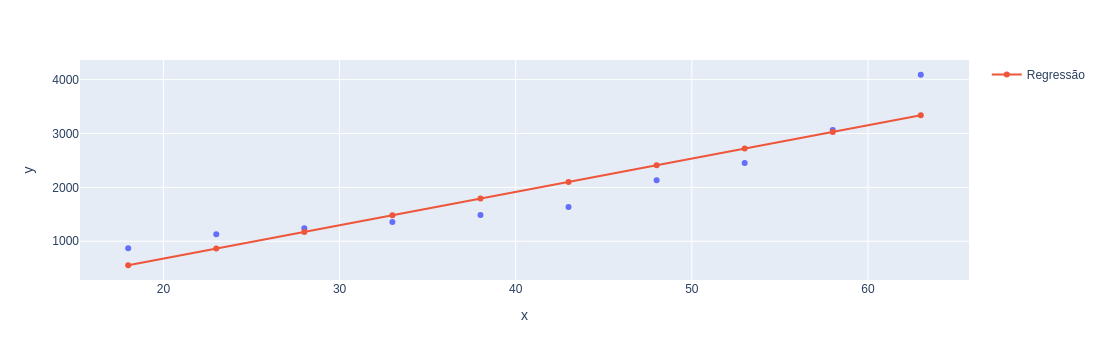

In [88]:
grafico = px.scatter(x = X_plano_saude.ravel(), y = y_plano_saude)#pontos em azul são os dados reais
grafico.add_scatter(x = X_plano_saude.ravel(), y = previsoes, name = 'Regressão') # colocar as previsões no gráfico
grafico.show()

In [92]:
# valor mais próximo previsto do real é o penúltimo dado. 

# previsão é uma reta, por aplicarmos a fórmula da regressão linear simples, equação de uma reta.

# y=b0+b1*x1

In [94]:

# y=b0+b1*(x1 =18 anos de idade), o predict cálcula com base nesta fórmula. 
regressor_plano_saude.intercept_ + regressor_plano_saude.coef_ * 18

array([554.67272727])

In [93]:

# y=b0+b1*(x1 =40 anos de idade), o predict cálcula com base nesta fórmula. 
regressor_plano_saude.intercept_ + regressor_plano_saude.coef_ * 40

array([1915.76606061])

In [96]:
# colocar dentro do predict o formato da matriz, dois colchetes [[]], mesmo valor da fórmula da equação da reta.
regressor_plano_saude.predict([[40]])

array([1915.76606061])

In [97]:
# métrica para ver quanto é bom o algoritmo de regressão, ou seja, a qualidade do algoritmo.
regressor_plano_saude.score(X_plano_saude, y_plano_saude)

0.8666112727879173

In [100]:
qualidade_algoritmo = regressor_plano_saude.score(X_plano_saude, y_plano_saude)

print('A acurácia do modelo é de {:.1f}%'.format(qualidade_algoritmo*100)) # quanto mais perto de 1, melhor é esse valor.

A acurácia do modelo é de 86.7%


https://www.scikit-yb.org/en/latest/

https://www.scikit-yb.org/en/latest/oneliners.html#feature-analysis

https://www.scikit-yb.org/en/latest/oneliners.html#clustering

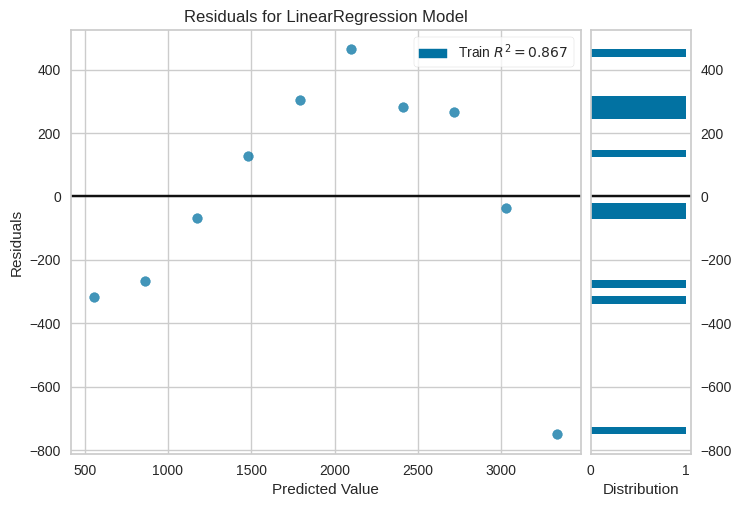

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [101]:
# analisar os dados residuais, de maneira mais elegante.
from yellowbrick.regressor import ResidualsPlot
visualizador = ResidualsPlot(regressor_plano_saude)
visualizador.fit(X_plano_saude, y_plano_saude)
visualizador.poof()


Dados residuais, que é a distância dos valores originais para a linha da regressão linear (previsão);

o quanto os dados estão afastados da linha de regressão. 

R^2, qualidade do algoritmo